In [43]:
import pandas as pd
import numpy as np
import pymc as pm
import pytensor.tensor as pt

In [66]:
player_data = pd.read_csv('./rolled_data_24_25.csv')
player_data = player_data[player_data['round']>3]
feats_gk = [
    'value', 'win_prob', 'points_1_ewm', 'xP_3_ewm', 'minutes_3_ewm', 'yellow_cards_3_ewm', 'clean_sheets_per_90_3_ewm', 'saves_per_90_3_ewm',
    'expected_goals_conceded_per_90_3_ewm',  'goals_prevented_per_90_3_ewm', 'sweeper_actions_per_90_3_ewm', 'opponent_xG_3_ewm', 'shots_faced_3_ewm'
    ]

In [67]:
# selected_by_percet = player_data[['round', 'selected_by_percent']].fillna(0)
# select_probs = (selected_by_percet['selected_by_percent']/selected_by_percet['selected_by_percent'].sum()).values
select_probs = player_data['league_select_probs'] + 1e-6
select_probs = select_probs / select_probs.sum()

assert np.isclose(select_probs.sum(), 1.0), "still not on the simplex"
assert (select_probs > 0).all(), "still has non-positive entries"

In [13]:
def fit_dirichlet_regression(X, P_observed):
    """
    Fits a Bayesian Dirichlet regression model using PyMC to estimate beta coefficients.


    Args:
        X (np.ndarray): The feature matrix for a specific position (e.g., GKs).
                        Shape should be (num_players, num_features).
        P_observed (np.ndarray): The observed historical ownership proportions for that position.
                                 Shape should be (num_players,). Must sum to 1.

    Returns:
        pm.backends.base.MultiTrace: The results of the MCMC simulation, containing posterior samples for beta.
    """
    n_players, n_features = X.shape

    with pm.Model() as dirichlet_model:
        # 1. Define priors for our beta coefficients. We'll use a flat (uninformative) prior as mentioned.
        # [span_0](start_span)This corresponds to p(beta) in equation (6)[span_0](end_span).
        # betas = pm.Uniform("betas", lower=-5, upper=5, shape=(n_features,)) #
        betas = pm.Normal("betas", mu=0, sigma=1, shape=(n_features,))

        # 2. Calculate alpha based on the linear model: alpha = exp(X * beta)
        # [span_1](start_span)This is equation (4) in the paper[span_1](end_span).
        alpha = pm.math.exp(pm.math.dot(X, betas)) + 1e-6

        # 3. Define the likelihood of our observed data P_observed
        # The observed ownership proportions are assumed to follow a Dirichlet distribution
        # parameterized by alpha. [span_2](start_span)[span_3](start_span)This is the core of the regression[span_2](end_span)[span_3](end_span).
        pm.Dirichlet('p_obs', a=alpha, observed=P_observed)

        # 4. Run the MCMC sampler to get the posterior distribution of beta
        print("Fitting Dirichlet regression model with PyMC...")
        trace = pm.sample(3000, tune=1000, chains=4, cores=4)
        print("✅ Model fitting complete.")

        # approx = pm.fit(n=2000, method='advi', progressbar=True)
        # trace = approx.sample(2000)

    return trace

# HJ


## G6


In [ ]:

player_data = player_data[player_data['round'] < 6]
# selected_by_percet = player_data[['round', 'selected_by_percent']].fillna(0)
# select_probs = (selected_by_percet['selected_by_percent']/selected_by_percet['selected_by_percent'].sum()).values
select_probs = player_data['league_select_probs'] + 1e-6
select_probs = select_probs / select_probs.sum()

assert np.isclose(select_probs.sum(), 1.0), "still not on the simplex"
assert (select_probs > 0).all(), "still has non-positive entries"

X_gk = player_data[feats_gk].to_numpy(dtype=float)   # <-- explicit conversion
assert not np.isnan(X_gk).any(), "NaNs in feats_gk"
assert not np.isinf(X_gk).any(), "Infs in feats_gk"
assert X_gk.shape[0] == select_probs.shape[0], "row mismatch between X and select_probs"



n_players, n_features = player_data[feats_gk].shape
print(n_players, n_features)
with pm.Model() as model:
    # p(beta_j) ∝ 1  -- the flat/uniform prior used in the theorem
    beta = pm.Flat("beta", shape=n_features)

    alpha = pm.math.exp(pt.dot(player_data[feats_gk], beta))
    alpha = pt.clip(alpha, 1e-6, 1e6)  # numerical guard, doesn't alter the model

    pm.Dirichlet(f"p", a=alpha, observed=select_probs)

    # 4. Run the MCMC sampler to get the posterior distribution of beta
    print("Fitting Dirichlet regression model with PyMC...")
    trace = pm.sample(2000, tune=2000, chains=4, cores=4)
    print("✅ Model fitting complete.")


Initializing NUTS using jitter+adapt_diag...


1320 14
Fitting Dirichlet regression model with PyMC...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 394 seconds.
There were 1673 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


✅ Model fitting complete.


In [68]:
# --- data (unchanged from your working version) -------------------------
player_data = player_data[player_data['round'] < 6]

select_probs = player_data['league_select_probs'] + 1e-6
select_probs = (select_probs / select_probs.sum()).to_numpy(dtype=float)

X_gk_raw = player_data[feats_gk].to_numpy(dtype=float)

assert not np.isnan(X_gk_raw).any()
assert not np.isinf(X_gk_raw).any()
assert X_gk_raw.shape[0] == select_probs.shape[0]

n_players, n_features = X_gk_raw.shape
print(n_players, n_features)

# --- NEW: standardize features (zero mean, unit variance) ---------------
X_mean = X_gk_raw.mean(axis=0)
X_std = X_gk_raw.std(axis=0)
X_std[X_std == 0] = 1.0  # guard against constant columns
X_gk = (X_gk_raw - X_mean) / X_std

# --- model ----------------------------------------------------------------
with pm.Model() as model:
    # NEW: weakly-informative proper prior instead of Flat.
    # sd=5 on standardized features is still very diffuse -- it constrains
    # the sampler's geometry without meaningfully changing the fit versus
    # a true flat prior for any beta an FPL dataset will actually produce.
    beta = pm.Normal("beta", mu=0.0, sigma=5.0, shape=n_features)

    alpha = pm.math.exp(pt.dot(X_gk, beta))
    alpha = pt.clip(alpha, 1e-6, 1e6)

    pm.Dirichlet("p", a=alpha, observed=select_probs)

    print("Fitting Dirichlet regression model with PyMC...")
    trace = pm.sample(
        2000, tune=2000, chains=4, cores=4,
        target_accept=0.95,     # NEW: was implicitly 0.8; higher = smaller, safer steps
        max_treedepth=12,       # NEW: give it more room before giving up on a trajectory
    )
    print("✅ Model fitting complete.")

# --- NEW: sanity-check the fit before trusting it ------------------------
import arviz as az
print(az.summary(trace, var_names=["beta"]))
print("\ndivergences:", int(trace.sample_stats["diverging"].sum()))

Initializing NUTS using jitter+adapt_diag...


1320 13
Fitting Dirichlet regression model with PyMC...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 14 seconds.


✅ Model fitting complete.
           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]   0.078  0.015   0.049    0.104        0.0      0.0    9130.0   
beta[1]   0.020  0.011  -0.000    0.042        0.0      0.0   10848.0   
beta[2]   0.076  0.015   0.048    0.104        0.0      0.0    9632.0   
beta[3]   0.162  0.020   0.124    0.201        0.0      0.0    7544.0   
beta[4]   0.017  0.019  -0.019    0.054        0.0      0.0    7394.0   
beta[5]  -0.020  0.012  -0.043    0.002        0.0      0.0   10737.0   
beta[6]  -0.032  0.014  -0.058   -0.006        0.0      0.0    9387.0   
beta[7]   0.056  0.016   0.025    0.086        0.0      0.0    6530.0   
beta[8]  -0.033  0.012  -0.054   -0.010        0.0      0.0   12186.0   
beta[9]  -0.012  0.011  -0.034    0.008        0.0      0.0    9630.0   
beta[10] -0.076  0.015  -0.104   -0.049        0.0      0.0    7306.0   
beta[11]  0.008  0.012  -0.014    0.031        0.0      0.0    8759.0   
beta[12] -0.024  0.011  -

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],0.08,0.01,0.05,0.10,0.0,0.0,9130.19,6269.32,1.0
beta[1],0.02,0.01,-0.00,0.04,0.0,0.0,10847.82,6396.99,1.0
beta[2],0.08,0.02,0.05,0.10,0.0,0.0,9631.66,5789.72,1.0
beta[3],0.16,0.02,0.12,0.20,0.0,0.0,7544.38,5880.90,1.0
beta[4],0.02,0.02,-0.02,0.05,0.0,0.0,7393.81,6130.78,1.0
beta[5],-0.02,0.01,-0.04,0.00,0.0,0.0,10737.12,5921.04,1.0
beta[6],-0.03,0.01,-0.06,-0.01,0.0,0.0,9387.31,5948.90,1.0
beta[7],0.06,0.02,0.02,0.09,0.0,0.0,6529.77,6012.33,1.0
beta[8],-0.03,0.01,-0.05,-0.01,0.0,0.0,12186.44,6103.21,1.0
beta[9],-0.01,0.01,-0.03,0.01,0.0,0.0,9629.82,6622.07,1.0


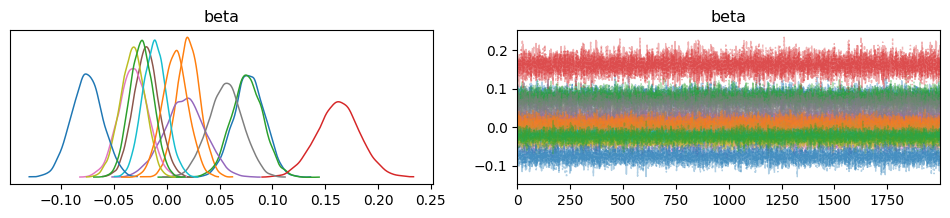

In [69]:
# trace_gk
az.plot_trace(trace, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary = az.summary(trace, var_names=["beta"], round_to=2)
summary

In [72]:
[feats_gk[i] for i in significant_indices]

['value',
 'points_1_ewm',
 'xP_3_ewm',
 'saves_per_90_3_ewm',
 'sweeper_actions_per_90_3_ewm']

In [ ]:
# 1. Pull out the beta[i] rows from the arviz summary
significant_beta_labels = summary[abs(summary['mean']) > 0.05].index
significant_indices = [int(label.split('[')[1].split(']')[0]) for label in significant_beta_labels]
feats_gk_cleaned = [feats_gk[i] for i in significant_indices]

# 2. X_gk is a numpy array (post-standardization), not a DataFrame --
#    index by integer position, not by column name
X_gk_cleaned = X_gk[:, significant_indices]

print(f"Kept {len(significant_indices)} of {len(feats_gk)} features")
print(feats_gk_cleaned)

# -----------------------------------------------------------------------
# OPTIONAL, but recommended: use the credible interval rather than a raw
# |mean| > 0.05 cutoff. A fixed magnitude threshold treats every beta as
# equally uncertain, but sd/HDI width can differ a lot between features
# even after standardization (e.g. rarer events -> wider posteriors).
# "Does the 94% HDI exclude zero?" is the standard Bayesian analogue of
# statistical significance and won't accidentally keep a feature whose
# mean happens to clear 0.05 purely from posterior noise, or drop one
# whose mean is small but very precisely estimated away from zero.
# -----------------------------------------------------------------------
credible_mask = (summary['hdi_3%'] > 0) | (summary['hdi_97%'] < 0)
credible_labels = summary[credible_mask].index
credible_indices = [int(label.split('[')[1].split(']')[0]) for label in credible_labels]
feats_gk_credible = [feats_gk[i] for i in credible_indices]

print(f"\nHDI-excludes-zero criterion keeps {len(credible_indices)} features:")
print(feats_gk_credible)

Kept 5 of 13 features
['value', 'points_1_ewm', 'xP_3_ewm', 'saves_per_90_3_ewm', 'sweeper_actions_per_90_3_ewm']

HDI-excludes-zero criterion keeps 7 features:
['value', 'points_1_ewm', 'xP_3_ewm', 'clean_sheets_per_90_3_ewm', 'saves_per_90_3_ewm', 'expected_goals_conceded_per_90_3_ewm', 'sweeper_actions_per_90_3_ewm']


In [74]:
# --- data (unchanged from your working version) -------------------------
player_data = player_data[player_data['round'] < 6]

select_probs = player_data['league_select_probs'] + 1e-6
select_probs = (select_probs / select_probs.sum()).to_numpy(dtype=float)

X_gk_raw = player_data[feats_gk_credible].to_numpy(dtype=float)

assert not np.isnan(X_gk_raw).any()
assert not np.isinf(X_gk_raw).any()
assert X_gk_raw.shape[0] == select_probs.shape[0]

n_players, n_features = X_gk_raw.shape
print(n_players, n_features)

# --- NEW: standardize features (zero mean, unit variance) ---------------
X_mean = X_gk_raw.mean(axis=0)
X_std = X_gk_raw.std(axis=0)
X_std[X_std == 0] = 1.0  # guard against constant columns
X_gk = (X_gk_raw - X_mean) / X_std

# --- model ----------------------------------------------------------------
with pm.Model() as model:
    # NEW: weakly-informative proper prior instead of Flat.
    # sd=5 on standardized features is still very diffuse -- it constrains
    # the sampler's geometry without meaningfully changing the fit versus
    # a true flat prior for any beta an FPL dataset will actually produce.
    beta = pm.Normal("beta", mu=0.0, sigma=5.0, shape=n_features)

    alpha = pm.math.exp(pt.dot(X_gk, beta))
    alpha = pt.clip(alpha, 1e-6, 1e6)

    pm.Dirichlet("p", a=alpha, observed=select_probs)

    print("Fitting Dirichlet regression model with PyMC...")
    trace = pm.sample(
        2000, tune=2000, chains=4, cores=4,
        target_accept=0.95,     # NEW: was implicitly 0.8; higher = smaller, safer steps
        max_treedepth=12,       # NEW: give it more room before giving up on a trajectory
    )
    print("✅ Model fitting complete.")

# --- NEW: sanity-check the fit before trusting it ------------------------
import arviz as az
print(az.summary(trace, var_names=["beta"]))
print("\ndivergences:", int(trace.sample_stats["diverging"].sum()))

Initializing NUTS using jitter+adapt_diag...


1320 7
Fitting Dirichlet regression model with PyMC...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 11 seconds.


✅ Model fitting complete.
          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]  0.078  0.015   0.048    0.104        0.0      0.0    7252.0   
beta[1]  0.074  0.014   0.047    0.101        0.0      0.0    6843.0   
beta[2]  0.166  0.017   0.135    0.200        0.0      0.0    6064.0   
beta[3] -0.035  0.014  -0.062   -0.010        0.0      0.0    7198.0   
beta[4]  0.054  0.015   0.026    0.082        0.0      0.0    6424.0   
beta[5] -0.029  0.012  -0.050   -0.007        0.0      0.0    7400.0   
beta[6] -0.074  0.015  -0.103   -0.047        0.0      0.0    6504.0   

         ess_tail  r_hat  
beta[0]    5985.0    1.0  
beta[1]    5404.0    1.0  
beta[2]    5379.0    1.0  
beta[3]    5734.0    1.0  
beta[4]    5747.0    1.0  
beta[5]    5709.0    1.0  
beta[6]    5483.0    1.0  

divergences: 0


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],0.08,0.01,0.05,0.10,0.0,0.0,7251.68,5984.93,1.0
beta[1],0.07,0.01,0.05,0.10,0.0,0.0,6842.76,5403.86,1.0
beta[2],0.17,0.02,0.14,0.20,0.0,0.0,6064.48,5379.16,1.0
beta[3],-0.04,0.01,-0.06,-0.01,0.0,0.0,7198.01,5734.37,1.0
beta[4],0.05,0.01,0.03,0.08,0.0,0.0,6424.20,5746.72,1.0
beta[5],-0.03,0.01,-0.05,-0.01,0.0,0.0,7399.52,5709.42,1.0
beta[6],-0.07,0.01,-0.10,-0.05,0.0,0.0,6504.06,5482.82,1.0


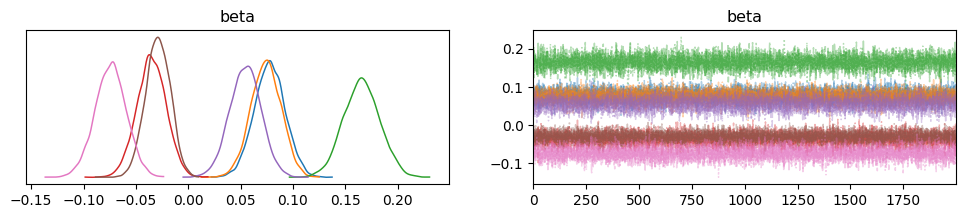

In [75]:
# trace_gk
az.plot_trace(trace, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary = az.summary(trace, var_names=["beta"], round_to=2)
summary

In [ ]:
"""
Cross-sectional league baseline: fit -> standardize -> prune -> refit pipeline,
generalized across positions (g, d, m, f). Wraps the exact recipe that worked
for goalkeepers so it can be reused for d/m/f without re-deriving it each time.
"""
def fit_dirichlet_regression(X, select_probs, n_features, sigma=5.0,
                              draws=2000, tune=2000, chains=4, cores=4,
                              target_accept=0.95, max_treedepth=12,
                              random_seed=None):
    """
    One NUTS fit of p ~ Dirichlet(exp(X @ beta)), beta ~ Normal(0, sigma).
    Returns (trace, summary_df).
    """
    with pm.Model() as model:
        beta = pm.Normal("beta", mu=0.0, sigma=sigma, shape=n_features)
        alpha = pm.math.exp(pt.dot(X, beta))
        alpha = pt.clip(alpha, 1e-6, 1e6)
        pm.Dirichlet("p", a=alpha, observed=select_probs)

        trace = pm.sample(
            draws, tune=tune, chains=chains, cores=cores,
            target_accept=target_accept, max_treedepth=max_treedepth,
            random_seed=random_seed,
        )

    summary = az.summary(trace, var_names=["beta"])
    n_div = int(trace.sample_stats["diverging"].sum())
    print(f"  divergences: {n_div}")
    if n_div > 0:
        print("  WARNING: divergences present -- treat this fit as provisional")
    return trace, summary


def _hdi_overlap(lo1, hi1, lo2, hi2):
    """
    Fraction of the *narrower* interval's width that's covered by the
    overlap with the other interval. 1.0 = one interval fully contains
    (or exactly equals) the other; 0.0 = no overlap at all.
    """
    overlap = max(0.0, min(hi1, hi2) - max(lo1, lo2))
    narrower_width = min(hi1 - lo1, hi2 - lo2)
    if narrower_width <= 0:
        return 0.0
    return overlap / narrower_width


def prune_by_hdi(summary, feats, overlap_threshold=0.8, verbose=True):
    """
    Keep only features whose 94% HDI excludes zero, AND deduplicate
    features whose HDIs are near-identical to one another (a sign the
    two are capturing essentially the same effect -- often leftover
    collinearity that survived the raw-feature correlation check,
    since it can also arise from *combinations* of correlated features
    rather than a single pairwise correlation).

    Greedy strategy: process candidates in order of decreasing |mean|
    (strongest effect first). A candidate is dropped if its HDI overlaps
    an already-kept feature's HDI by more than `overlap_threshold`
    (as a fraction of the narrower interval's width) -- i.e. the weaker
    of the two near-duplicate effects is the one that goes.

    Returns (kept_feats, kept_indices).
    """
    mask = (summary['hdi_3%'] > 0) | (summary['hdi_97%'] < 0)
    sig = summary[mask].copy()
    labels = sig.index.tolist()
    indices = [int(lbl.split('[')[1].split(']')[0]) for lbl in labels]

    if len(sig) == 0:
        return [], []

    # process strongest effect first, so a redundant *weaker* duplicate
    # is the one dropped rather than an arbitrary member of the pair
    order = np.argsort(-sig['mean'].abs().to_numpy())

    kept_local = []
    for i in order:
        lo_i, hi_i = sig['hdi_3%'].iloc[i], sig['hdi_97%'].iloc[i]
        redundant_with = None
        for k in kept_local:
            lo_k, hi_k = sig['hdi_3%'].iloc[k], sig['hdi_97%'].iloc[k]
            if _hdi_overlap(lo_i, hi_i, lo_k, hi_k) > overlap_threshold:
                redundant_with = k
                break
        if redundant_with is None:
            kept_local.append(i)
        elif verbose:
            print(f"  dropping {feats[indices[i]]!r} (label {labels[i]}) -- "
                  f"HDI near-duplicate of {feats[indices[redundant_with]]!r} "
                  f"(label {labels[redundant_with]})")

    kept_local = sorted(kept_local)  # restore original feature order
    kept_indices = [indices[i] for i in kept_local]
    kept_feats = [feats[i] for i in kept_indices]
    return kept_feats, kept_indices


def fit_position_pipeline(player_data, feats, select_probs_col='league_select_probs',
                           position_name='', eps=1e-6, random_seed=None):
    """
    Full pipeline for one position:
      1. Build X (raw features) and select_probs from player_data.
      2. Standardize X.
      3. Fit Dirichlet regression with a weakly-informative prior.
      4. Prune features whose 94% HDI includes zero.
      5. Re-standardize on the pruned feature set and refit.

    Returns a dict with everything needed to reuse this model later
    (predicting alpha_{j,T}^league on a new week's features).
    """
    print(f"\n{'=' * 60}\nPosition: {position_name}\n{'=' * 60}")

    # --- 1. raw data -----------------------------------------------------
    select_probs = player_data[select_probs_col] + eps
    select_probs = (select_probs / select_probs.sum()).to_numpy(dtype=float)

    X_raw = player_data[feats].to_numpy(dtype=float)
    assert not np.isnan(X_raw).any(), f"NaNs in features for {position_name}"
    assert not np.isinf(X_raw).any(), f"Infs in features for {position_name}"
    assert X_raw.shape[0] == select_probs.shape[0], "row mismatch"

    n_players, n_features = X_raw.shape
    print(f"n_players={n_players}, n_features={n_features}")

    # --- 2. standardize ----------------------------------------------------
    X_mean = X_raw.mean(axis=0)
    X_std = X_raw.std(axis=0)
    X_std[X_std == 0] = 1.0
    X = (X_raw - X_mean) / X_std

    # --- 3. initial fit ------------------------------------------------------
    print("Fitting initial model...")
    trace, summary = fit_dirichlet_regression(
        X, select_probs, n_features, random_seed=random_seed
    )


    print(az.summary(trace, var_names=["beta"]))
    print(az.plot_trace(trace, combined=True))
    # --- 4. prune ------------------------------------------------------------
    feats_kept, idx_kept = prune_by_hdi(summary, feats)
    print(f"Kept {len(feats_kept)} / {len(feats)} features: {feats_kept}")

    if len(feats_kept) == 0:
        print("WARNING: no features survived pruning -- keeping full set instead")
        feats_kept, idx_kept = feats, list(range(n_features))

    # --- 5. refit on pruned features ------------------------------------------
    X_raw_kept = X_raw[:, idx_kept]
    X_mean_kept = X_raw_kept.mean(axis=0)
    X_std_kept = X_raw_kept.std(axis=0)
    X_std_kept[X_std_kept == 0] = 1.0
    X_kept = (X_raw_kept - X_mean_kept) / X_std_kept

    print("Refitting on pruned feature set...")
    trace_final, summary_final = fit_dirichlet_regression(
        X_kept, select_probs, len(feats_kept), random_seed=random_seed
    )



    print(az.summary(trace_final, var_names=["beta"]))
    print(az.plot_trace(trace_final, combined=True))
    return {
        "position": position_name,
        "feats": feats_kept,
        "X_mean": X_mean_kept,
        "X_std": X_std_kept,
        "trace": trace,
        "summary": summary,
        "trace_final": trace_final,
        "summary_final": summary_final,
        "beta_mean": trace_final.posterior["beta"].mean(dim=("chain", "draw")).values,
    }


def alpha_league(fit_result, X_new_raw):
    """
    Apply a fitted position model (dict returned by fit_position_pipeline) to
    new-week raw features, standardizing with the model's *training*
    mean/std, per eq:alpha_league.
    """
    X_std_new = (X_new_raw - fit_result["X_mean"]) / fit_result["X_std"]
    linear = np.clip(X_std_new @ fit_result["beta_mean"], -30, 30)
    return np.exp(linear)



Initializing NUTS using jitter+adapt_diag...



Position: gk
n_players=1320, n_features=13
Fitting initial model...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 13 seconds.


...

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 22 seconds.


  divergences: 0
[[<Axes: title={'center': 'beta'}> <Axes: title={'center': 'beta'}>]]

Position: mid
n_players=1320, n_features=51
Fitting initial model...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta]


Output()

KeyError: 0

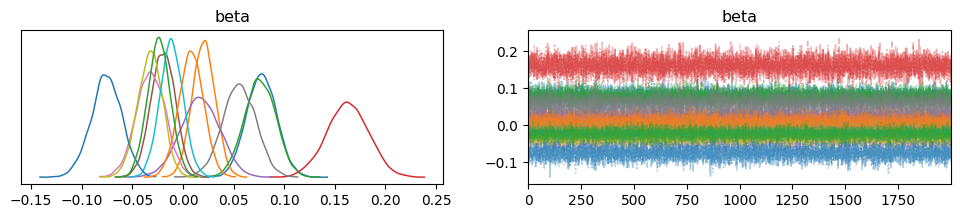

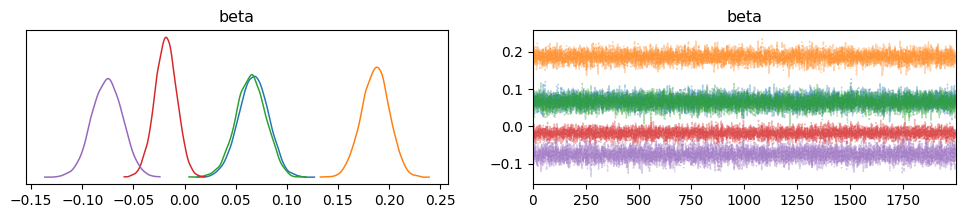

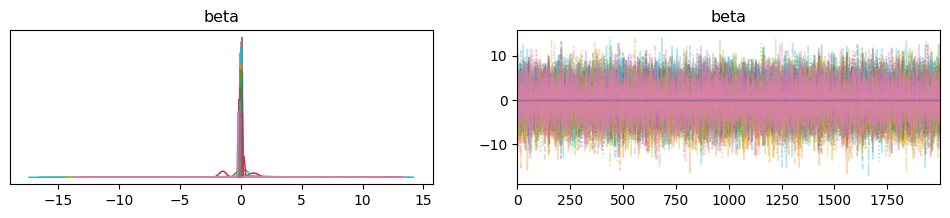

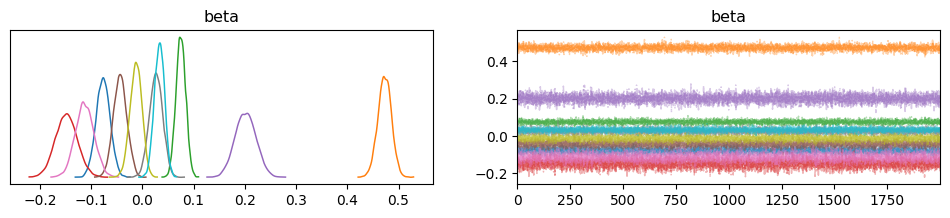

In [80]:
feats_gk = [
    'value', 'win_prob', 'points_1_ewm', 'xP_3_ewm', 'minutes_3_ewm', 'yellow_cards_3_ewm', 'clean_sheets_per_90_3_ewm', 'saves_per_90_3_ewm',
    'expected_goals_conceded_per_90_3_ewm',  'goals_prevented_per_90_3_ewm', 'sweeper_actions_per_90_3_ewm', 'opponent_xG_3_ewm', 'shots_faced_3_ewm'
    ]

feats_def = [
    'was_home', 'value', 'transfers_balance', 'selected', 'transfers_in', 'transfers_out', 'difficulty', 'opponent_difficulty', 'win_prob',
    'percentage_net_transfers','team_elo', 'opponent_elo', 'selected_by_percent', 'ownership_change',

    'clean_sheets_per_90_3_ewm', 'saves_per_90_3_ewm',
    'expected_goals_conceded_per_90_3_ewm',  'goals_prevented_per_90_3_ewm', 'sweeper_actions_per_90_3_ewm', 'opponent_xG_3_ewm', 'shots_faced_3_ewm',

    'points_3_ewm', 'xP_3_ewm', 'minutes_3_ewm',  'goals_scored_3_ewm', 'assists_3_ewm', 'yellow_cards_3_ewm', 'ict_index_3_ewm',
    'starts_3_ewm', 'expected_goals_3_ewm', 'expected_assists_3_ewm', 'expected_goal_involvements_3_ewm', 'interceptions_3_ewm', 'recoveries_3_ewm',
    'blocks_3_ewm', 'clearances_3_ewm', 'tackles_3_ewm', 'total_shots_3_ewm', 'chances_created_3_ewm', 'sweeper_actions_3_ewm',
    'tackles_won_percent_3_ewm', 'team_xG_3_ewm',  'total_points_per_90_3_ewm', 'goals_scored_per_90_3_ewm', 'assists_per_90_3_ewm',
    'saves_per_90_3_ewm', 'expected_goals_per_90_3_ewm', 'expected_assists_per_90_3_ewm', 'expected_goal_involvements_per_90_3_ewm',
    'interceptions_per_90_3_ewm', 'recoveries_per_90_3_ewm', 'blocks_per_90_3_ewm', 'clearances_per_90_3_ewm', 'tackles_per_90_3_ewm',
    'total_shots_per_90_3_ewm', 'chances_created_per_90_3_ewm', 'sweeper_actions_per_90_3_ewm', 'tackles_won_percent_per_90_3_ewm',
    ]

feats_mid = [
    'was_home', 'value', 'transfers_balance', 'selected', 'transfers_in', 'transfers_out', 'difficulty', 'opponent_difficulty', 'win_prob',
    'percentage_net_transfers','team_elo', 'opponent_elo', 'selected_by_percent', 'ownership_change',

    'points_3_ewm', 'xP_3_ewm', 'minutes_3_ewm',  'goals_scored_3_ewm', 'assists_3_ewm', 'yellow_cards_3_ewm', 'ict_index_3_ewm',
    'starts_3_ewm', 'expected_goals_3_ewm', 'expected_assists_3_ewm', 'expected_goal_involvements_3_ewm', 'interceptions_3_ewm', 'recoveries_3_ewm',
    'blocks_3_ewm', 'clearances_3_ewm', 'tackles_3_ewm', 'total_shots_3_ewm', 'chances_created_3_ewm', 'sweeper_actions_3_ewm',
    'tackles_won_percent_3_ewm', 'team_xG_3_ewm',  'total_points_per_90_3_ewm', 'goals_scored_per_90_3_ewm', 'assists_per_90_3_ewm',
    'saves_per_90_3_ewm', 'expected_goals_per_90_3_ewm', 'expected_assists_per_90_3_ewm', 'expected_goal_involvements_per_90_3_ewm',
    'interceptions_per_90_3_ewm', 'recoveries_per_90_3_ewm', 'blocks_per_90_3_ewm', 'clearances_per_90_3_ewm', 'tackles_per_90_3_ewm',
    'total_shots_per_90_3_ewm', 'chances_created_per_90_3_ewm', 'sweeper_actions_per_90_3_ewm', 'tackles_won_percent_per_90_3_ewm',
    ]

feats_fwd = [
    'was_home', 'value', 'transfers_balance', 'selected', 'transfers_in', 'transfers_out', 'difficulty', 'opponent_difficulty', 'win_prob',
    'percentage_net_transfers','team_elo', 'opponent_elo', 'selected_by_percent', 'ownership_change',

    'points_3_ewm', 'xP_3_ewm', 'minutes_3_ewm',  'goals_scored_3_ewm', 'assists_3_ewm', 'yellow_cards_3_ewm', 'ict_index_3_ewm',
    'starts_3_ewm', 'expected_goals_3_ewm', 'expected_assists_3_ewm', 'expected_goal_involvements_3_ewm', 'interceptions_3_ewm', 'recoveries_3_ewm',
    'blocks_3_ewm', 'clearances_3_ewm', 'tackles_3_ewm', 'total_shots_3_ewm', 'chances_created_3_ewm', 'sweeper_actions_3_ewm',
    'tackles_won_percent_3_ewm', 'team_xG_3_ewm',  'total_points_per_90_3_ewm', 'goals_scored_per_90_3_ewm', 'assists_per_90_3_ewm',
    'saves_per_90_3_ewm', 'expected_goals_per_90_3_ewm', 'expected_assists_per_90_3_ewm', 'expected_goal_involvements_per_90_3_ewm',
    'interceptions_per_90_3_ewm', 'recoveries_per_90_3_ewm', 'blocks_per_90_3_ewm', 'clearances_per_90_3_ewm', 'tackles_per_90_3_ewm',
    'total_shots_per_90_3_ewm', 'chances_created_per_90_3_ewm', 'sweeper_actions_per_90_3_ewm', 'tackles_won_percent_per_90_3_ewm',
    ]

# --- run across all four positions ------------------------------------
position_configs = {
    "gk": feats_gk,
    "def": feats_def,
    "mid": feats_mid,
    "fwd": feats_fwd,
}

league_models = {}
for j, feats_j in position_configs.items():
    league_models[j] = fit_position_pipeline(
        player_data, feats_j, position_name=j, random_seed=42
    )

print("\nAll positions fit. Summary:")
for j, res in league_models.items():
    print(f"  {j}: {len(res['feats'])} features kept -> {res['feats']}")